In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\studentsdata\StudentPerformanceFactors.csv")

In [12]:
print(df.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [13]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [14]:
print(df.describe())

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.235659  
std             1.230570           1.031231     3.890456  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.000000  
50%             1.000000           3.00000

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

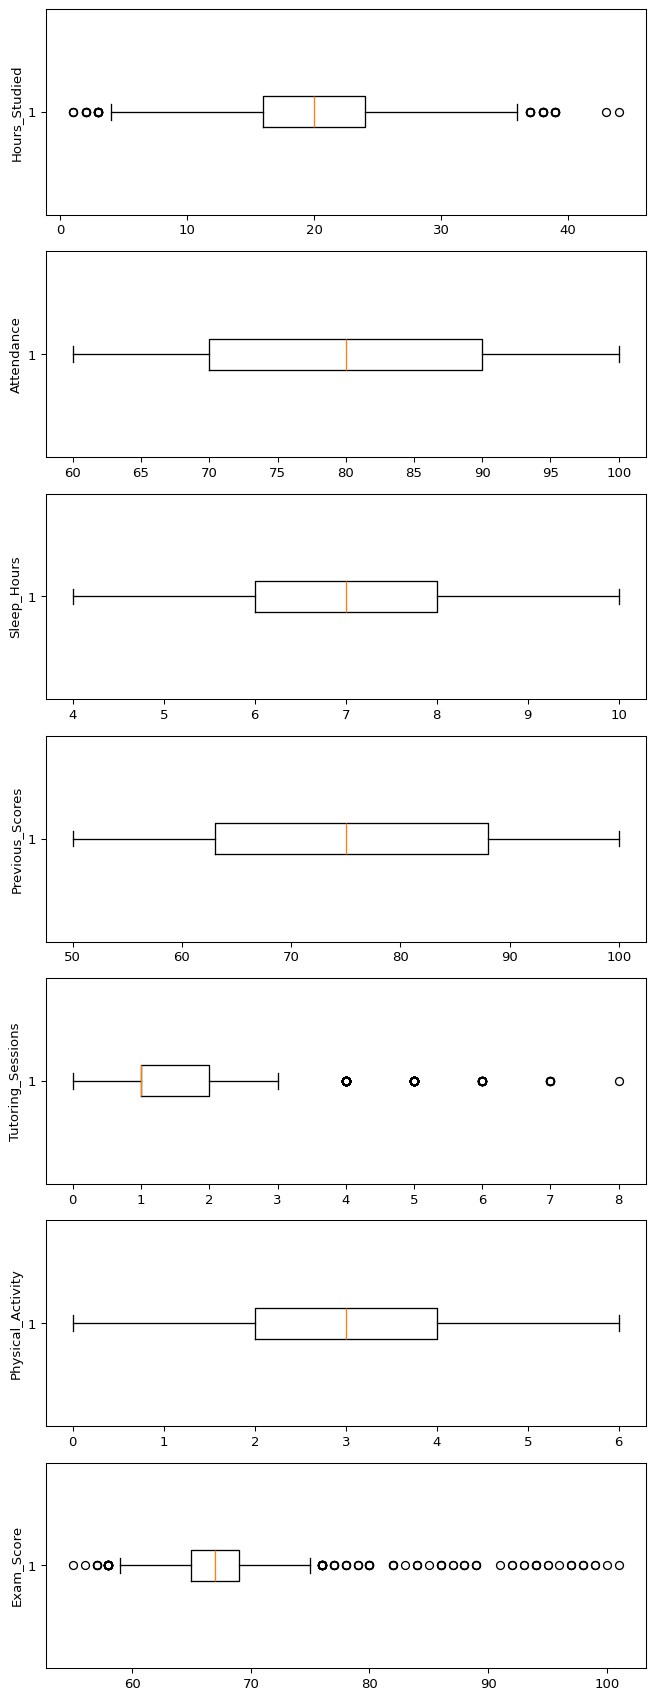

In [16]:
fig, axs = plt.subplots(len(num_cols), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(num_cols):
    axs[i].boxplot(df[col].dropna(), vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [17]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
clean_df = df.copy()

print(f"Shape before removing outliers: {clean_df.shape}")

for col in num_cols:
    q1, q3 = np.percentile(clean_df[col].dropna(), [25, 75])
    
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper) | clean_df[col].isnull()]

print(f"Shape after removing outliers: {clean_df.shape}")

Shape before removing outliers: (6607, 20)
Shape after removing outliers: (6054, 20)


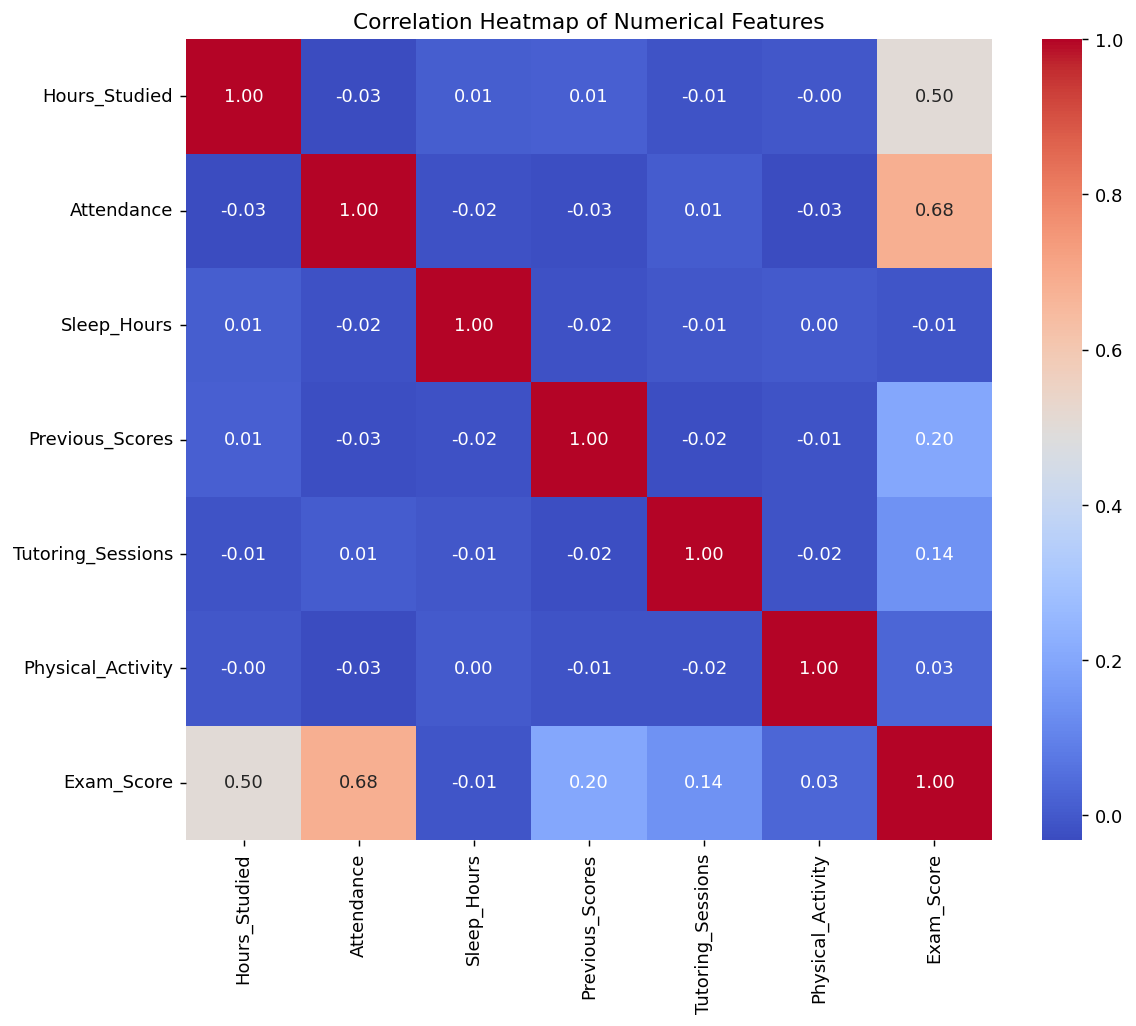

--- Correlation with Exam_Score ---
Exam_Score           1.000000
Attendance           0.682257
Hours_Studied        0.500809
Previous_Scores      0.198775
Tutoring_Sessions    0.140999
Physical_Activity    0.030135
Sleep_Hours         -0.009101
Name: Exam_Score, dtype: float64


In [18]:

numeric_df = clean_df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
plt.figure(dpi=130, figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()
print("--- Correlation with Exam_Score ---")
print(corr['Exam_Score'].sort_values(ascending=False))

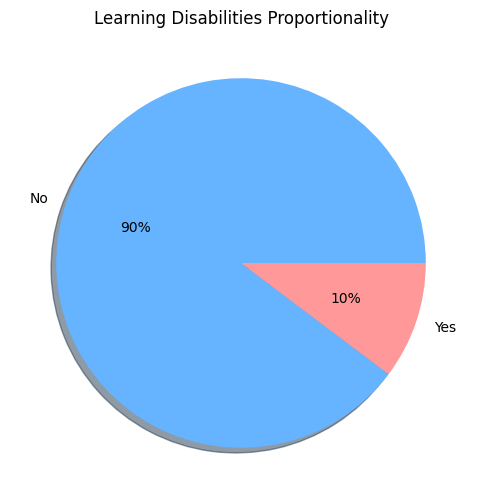

In [19]:

counts = clean_df['Learning_Disabilities'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts, 
        labels=counts.index, # 
        autopct='%.f%%', 
        shadow=True,
        colors=['#66b3ff', '#ff9999']) 

plt.title('Learning Disabilities Proportionality')
plt.show()

In [20]:

X = clean_df.drop(columns=['Exam_Score'])

y = clean_df['Exam_Score']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (6054, 19)
Target (y) shape: (6054,)


In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_num = X.select_dtypes(include=['int64', 'float64'])
X_normalized = scaler.fit_transform(X_num)

print("--- Normalized Features (First 5 Rows) ---")
print(X_normalized[:5])

--- Normalized Features (First 5 Rows) ---
[[0.59375    0.6        0.5        0.46       0.         0.5       ]
 [0.46875    0.1        0.66666667 0.18       0.66666667 0.66666667]
 [0.625      0.95       0.5        0.82       0.66666667 0.66666667]
 [0.78125    0.725      0.66666667 0.96       0.33333333 0.66666667]
 [0.46875    0.8        0.33333333 0.3        1.         0.66666667]]


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_num = X.select_dtypes(include=['int64', 'float64'])


X_standardized = scaler.fit_transform(X_num)

print("--- Standardized Features (First 5 Rows) ---")
print(X_standardized[:5])

--- Standardized Features (First 5 Rows) ---
[[ 0.51607005  0.35028263 -0.02337709 -0.14711688 -1.31493171  0.037064  ]
 [-0.1764848  -1.38920638  0.65703117 -1.1224034   0.71842629  1.00842965]
 [ 0.68920876  1.56792494 -0.02337709  1.10682294  0.71842629  1.00842965]
 [ 1.55490232  0.78515488  0.65703117  1.5944662  -0.29825271  1.00842965]
 [-0.1764848   1.04607824 -0.70378535 -0.70442346  1.73510529  1.00842965]]
